In [13]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

np.set_printoptions(precision=6, suppress=False)

# Cambia esta ruta si tu archivo está en otra carpeta
H5FILE = Path("sl_spectrum_rmax_10000_Ggrid_drmax2_rflat1000.h5")

# Número de modos usados para pruebas pesadas de ortogonalidad/residuo
N_CHECK = 300

# Número de modos para graficar
N_PLOT = 8

assert H5FILE.exists(), f"No encuentro el archivo: {H5FILE}"

In [14]:
def pcoef(x):
    x = np.asarray(x, dtype=np.float64)
    return x**2 / np.sqrt(1.0 + 1.0/x)

def wcoef(x):
    x = np.asarray(x, dtype=np.float64)
    return x**2 * np.sqrt(1.0 + 1.0/x)

def grid_quantities(r):
    """
    r viene guardada como r[0],...,r[Nr+1].
    Los puntos físicos interiores son r[1:-1].
    """
    r = np.asarray(r, dtype=np.float64)
    dr_edge = np.diff(r)              # dr_edge[0],...,dr_edge[Nr]
    ri = r[1:-1]                      # interiores: i=1,...,Nr
    drc = 0.5*(dr_edge[:-1] + dr_edge[1:])
    M = wcoef(ri)*drc
    return ri, dr_edge, drc, M

def build_A_M(r, ell):
    """
    Reconstruye el problema generalizado A R = lambda M R
    siguiendo exactamente la discretización del código Fortran.

    A es tridiagonal:
        diag = b_i
        off  = -p_{i+1/2}/dr_i

    M es diagonal:
        M_i = w(r_i)*drc_i
    """
    r = np.asarray(r, dtype=np.float64)
    ri, dr_edge, drc, M = grid_quantities(r)
    Nr = ri.size

    p_minus = pcoef(0.5*(r[:-2] + r[1:-1]))   # p_{i-1/2}
    p_plus  = pcoef(0.5*(r[1:-1] + r[2:]))    # p_{i+1/2}

    q = ell*(ell + 1.0)*np.sqrt(1.0 + 1.0/ri)

    diag = p_plus/dr_edge[1:] + p_minus/dr_edge[:-1] + q*drc

    # Frontera izquierda:
    # ell=0: R_0 = R_1
    # ell>0: R_0 = 0
    if ell == 0:
        diag[0] -= p_minus[0]/dr_edge[0]

    # Frontera derecha:
    # Neumann: R_{Nr+1} = R_Nr
    diag[-1] -= p_plus[-1]/dr_edge[-1]

    # Off-diagonal A_{i,i+1}
    off = -pcoef(0.5*(r[1:-2] + r[2:-1])) / dr_edge[1:-1]

    # Operador simetrizado B = M^{-1/2} A M^{-1/2}
    Bdiag = diag/M
    Boff = off/np.sqrt(M[:-1]*M[1:])

    return diag, off, M, Bdiag, Boff

def apply_tridiag(diag, off, X):
    """
    Aplica una matriz tridiagonal a un vector o a una matriz de vectores.
    diag: shape (Nr,)
    off:  shape (Nr-1,)
    X:    shape (Nr,) o (Nr,n)
    """
    X = np.asarray(X)
    vector_input = (X.ndim == 1)
    if vector_input:
        X = X[:, None]

    Y = diag[:, None]*X
    Y[:-1, :] += off[:, None]*X[1:, :]
    Y[1:, :]  += off[:, None]*X[:-1, :]

    return Y[:, 0] if vector_input else Y

In [ ]:
def list_h5(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"{name:30s} dataset shape={obj.shape}, dtype={obj.dtype}")
    else:
        print(f"{name:30s} group")

def get_ell_groups(f):
    groups = []
    for key in f.keys():
        if key.startswith("ell_"):
            groups.append(key)
    return sorted(groups)

def read_params(f):
    out = {}
    if "params" in f:
        if "real" in f["params"]:
            pr = f["params/real"][:]
            out["r_max"]  = pr[0]
            out["dr_min"] = pr[1]
            out["dr_max"] = pr[2]
            out["r_flat"] = pr[3]
        if "integer" in f["params"]:
            pi = f["params/integer"][:]
            out["Nr"]          = int(pi[0])
            out["N_intervals"] = int(pi[1])
            out["ell_max"]     = int(pi[2])
            out["n_modes"]     = int(pi[3])
            out["n_save"]      = int(pi[4])
    return out

def read_modes_for_ell(f, ell):
    group = f[f"ell_{ell:04d}"]
    k = group["k"][:]
    A = group["modes"][:]

    # Fortran guardó Z(i,n); h5py lo lee como A(n,i)
    R = A.T

    return k, np.asarray(R, dtype=np.float64)

with h5py.File(H5FILE, "r") as f:
    print("Contenido del archivo:")
    f.visititems(list_h5)

    print("\nParámetros:")
    params = read_params(f)
    for key, val in params.items():
        print(f"{key:14s} = {val}")

    ell_groups = get_ell_groups(f)
    print("\nGrupos ell encontrados:")
    print(ell_groups)

Contenido del archivo:
ell_0000                       group
ell_0000/k                     dataset shape=(5125,), dtype=float64
ell_0000/modes                 dataset shape=(5125, 5125), dtype=float64
ell_0001                       group
ell_0001/k                     dataset shape=(5125,), dtype=float64
ell_0001/modes                 dataset shape=(5125, 5125), dtype=float64
ell_0002                       group
ell_0002/k                     dataset shape=(5125,), dtype=float64
ell_0002/modes                 dataset shape=(5125, 5125), dtype=float64
ell_0003                       group
ell_0003/k                     dataset shape=(5125,), dtype=float64
ell_0003/modes                 dataset shape=(5125, 5125), dtype=float64
ell_0004                       group
ell_0004/k                     dataset shape=(5125,), dtype=float64
ell_0004/modes                 dataset shape=(5125, 5125), dtype=float64
ell_0005                       group
ell_0005/k                     dataset shape=(5125

In [16]:
with h5py.File(H5FILE, "r") as f:
    r = f["r"][:]
    params = read_params(f)

ri, dr_edge, drc, M = grid_quantities(r)

print("Resumen de malla")
print(f"len(r)              = {len(r)}")
print(f"Nr inferido         = {len(r)-2}")
print(f"r[0]                = {r[0]:.16e}")
print(f"r[-1]               = {r[-1]:.16e}")
print(f"primer interior     = {ri[0]:.16e}")
print(f"último interior     = {ri[-1]:.16e}")
print(f"min dr_edge         = {dr_edge.min():.16e}")
print(f"max dr_edge         = {dr_edge.max():.16e}")
print(f"min M               = {M.min():.16e}")
print(f"max M               = {M.max():.16e}")
print(f"malla monótona      = {np.all(np.diff(r) > 0)}")
print(f"M_i positivos       = {np.all(M > 0)}")

i_hor = np.argmin(np.abs(r - 1.0))
print(f"\nNodo más cercano a r=1: i={i_hor}, r={r[i_hor]:.16e}, |r-1|={abs(r[i_hor]-1):.3e}")

if "r_flat" in params:
    i_flat = np.argmin(np.abs(r - params["r_flat"]))
    print(f"Nodo más cercano a r_flat={params['r_flat']}: i={i_flat}, r={r[i_flat]:.16e}")

Resumen de malla
len(r)              = 5127
Nr inferido         = 5125
r[0]                = 0.0000000000000000e+00
r[-1]               = 1.0000000000000000e+04
primer interior     = 1.0000000000000001e-01
último interior     = 9.9993883475181465e+03
min dr_edge         = 9.9999999999999978e-02
max dr_edge         = 2.0000000000001137e+00
min M               = 3.3166247903554007e-03
max M               = 1.9990554468054324e+08
malla monótona      = True
M_i positivos       = True

Nodo más cercano a r=1: i=10, r=9.9999999999999989e-01, |r-1|=1.110e-16
Nodo más cercano a r_flat=1000.0: i=625, r=9.9938852454259631e+02


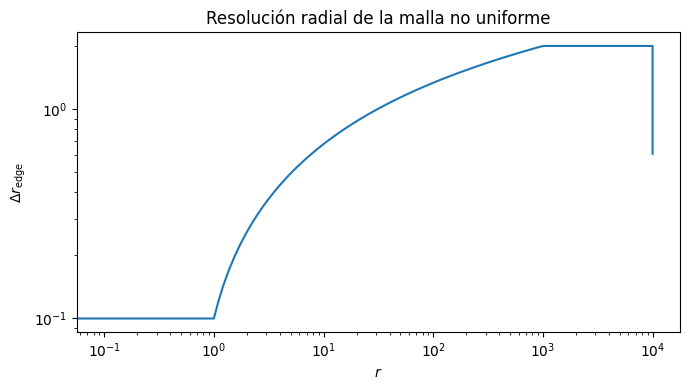

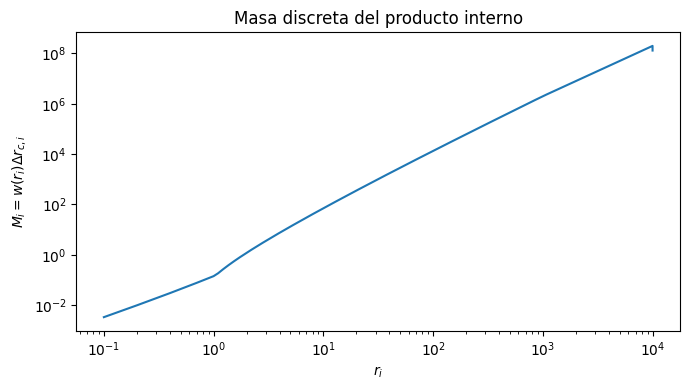

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(r[:-1], dr_edge, lw=1.5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$\Delta r_{\mathrm{edge}}$")
ax.set_title("Resolución radial de la malla no uniforme")
ax.grid(False)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(ri, M, lw=1.5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$r_i$")
ax.set_ylabel(r"$M_i = w(r_i)\Delta r_{c,i}$")
ax.set_title("Masa discreta del producto interno")
ax.grid(False)

plt.tight_layout()
plt.show()

In [18]:
def local_dr_py(x, dr_min, dr_max, r_flat):
    if x <= 1.0:
        return dr_min
    elif x >= r_flat:
        return dr_max
    else:
        denom = np.log(r_flat*(r_flat + 1.0)/2.0)
        xi = np.log(x*(x + 1.0)/2.0)/denom
        return dr_min + (dr_max - dr_min)*xi

def next_dr_py(x, r_max, dr_min, dr_max, r_flat, eps=1.0e-12):
    dx = local_dr_py(x, dr_min, dr_max, r_flat)

    # Forzar r=1 como nodo
    if x < 1.0 - eps and x + dx > 1.0:
        dx = 1.0 - x

    # Forzar r_max como nodo final
    if x + dx > r_max:
        dx = r_max - x

    return dx

def build_grid_py(r_max, dr_min, dr_max, r_flat, eps=1.0e-12):
    xs = [0.0]
    while xs[-1] < r_max - eps:
        dx = next_dr_py(xs[-1], r_max, dr_min, dr_max, r_flat, eps=eps)
        if dx <= 0:
            raise RuntimeError(f"dx <= 0 en x={xs[-1]}, dx={dx}")
        xs.append(xs[-1] + dx)
    xs[-1] = r_max
    return np.array(xs, dtype=np.float64)

with h5py.File(H5FILE, "r") as f:
    r = f["r"][:]
    params = read_params(f)

r_regen = build_grid_py(
    params["r_max"], params["dr_min"], params["dr_max"], params["r_flat"]
)

print(f"len(r guardada)     = {len(r)}")
print(f"len(r regenerada)   = {len(r_regen)}")

if len(r) == len(r_regen):
    diff = np.abs(r - r_regen)
    print(f"max |r - r_regen|   = {diff.max():.3e}")
    print(f"mean |r - r_regen|  = {diff.mean():.3e}")
else:
    print("Las longitudes no coinciden; revisar count_grid/build_grid.")

len(r guardada)     = 5127
len(r regenerada)   = 5127
max |r - r_regen|   = 0.000e+00
mean |r - r_regen|  = 0.000e+00


In [20]:
rows = []

with h5py.File(H5FILE, "r") as f:
    for group in get_ell_groups(f):
        ell = int(group.split("_")[1])
        k, R = read_modes_for_ell(f, ell)

        rows.append({
            "ell": ell,
            "Nr": R.shape[0],
            "n_modes": R.shape[1],
            "k_min": np.min(k),
            "k_max": np.max(k),
            "num_k_le_10": int(np.sum(k <= 10.0)),
            "monotonic_k": bool(np.all(np.diff(k) >= 0.0)),
            "modes_shape": str(R.shape),
        })

df_spectrum = pd.DataFrame(rows)
df_spectrum

,ell,Nr,n_modes,k_min,k_max,num_k_le_10,monotonic_k,modes_shape
0,0,5125,5125,8.913560e-09,13.345057,5121,True,"(5125, 5125)"
1,1,5125,5125,2.081629e-04,15.087022,5120,True,"(5125, 5125)"
2,2,5125,5125,3.342172e-04,25.032154,5118,True,"(5125, 5125)"
3,3,5125,5125,4.514206e-04,35.019628,5117,True,"(5125, 5125)"
4,4,5125,5125,5.646839e-04,45.014245,5116,True,"(5125, 5125)"
5,5,5125,5125,6.756622e-04,55.011240,5116,True,"(5125, 5125)"


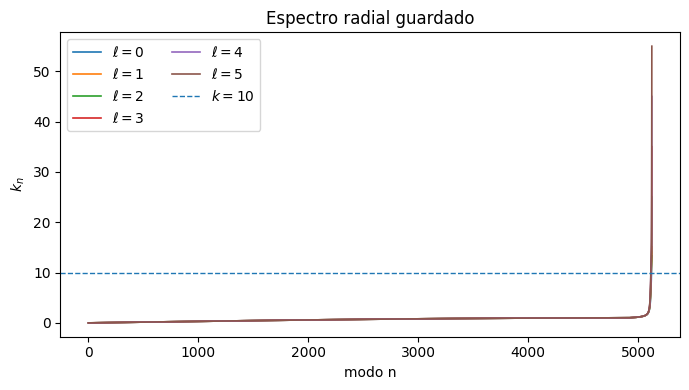

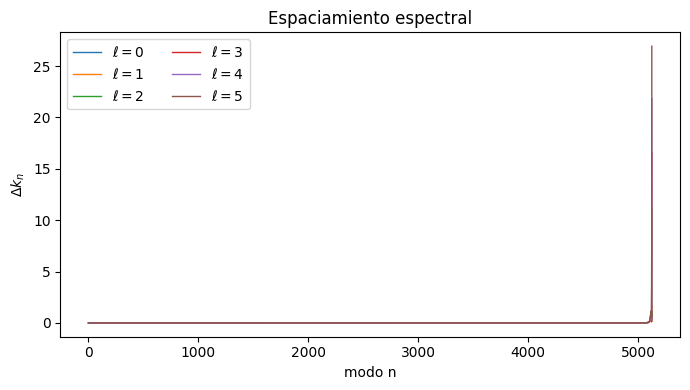

In [21]:
ells_to_plot = [0, 1, 2, 3, 4, 5]

with h5py.File(H5FILE, "r") as f:
    fig, ax = plt.subplots(figsize=(7, 4))

    for ell in ells_to_plot:
        if f"ell_{ell:04d}" not in f:
            continue
        k, R = read_modes_for_ell(f, ell)
        n = np.arange(1, len(k) + 1)
        ax.plot(n, k, lw=1.2, label=fr"$\ell={ell}$")

    ax.axhline(10.0, ls="--", lw=1.0, label=r"$k=10$")
    ax.set_xlabel("modo n")
    ax.set_ylabel(r"$k_n$")
    ax.set_title("Espectro radial guardado")
    ax.legend(ncol=2)
    ax.grid(False)

    plt.tight_layout()
    plt.show()

with h5py.File(H5FILE, "r") as f:
    fig, ax = plt.subplots(figsize=(7, 4))

    for ell in ells_to_plot:
        if f"ell_{ell:04d}" not in f:
            continue
        k, R = read_modes_for_ell(f, ell)
        dk = np.diff(k)
        ax.plot(np.arange(1, len(dk) + 1), dk, lw=1.0, label=fr"$\ell={ell}$")

    ax.set_xlabel("modo n")
    ax.set_ylabel(r"$\Delta k_n$")
    ax.set_title("Espaciamiento espectral")
    ax.legend(ncol=2)
    ax.grid(False)

    plt.tight_layout()
    plt.show()

In [22]:
def orthonormality_report(f, ell, n_check=300):
    r = f["r"][:]
    ri, dr_edge, drc, M = grid_quantities(r)
    k, R = read_modes_for_ell(f, ell)

    n = min(n_check, R.shape[1])
    Rn = R[:, :n]

    C = (Rn*M[:, None]).T @ Rn

    diag = np.diag(C)
    off = C - np.diag(diag)

    return {
        "ell": ell,
        "n_check": n,
        "max_abs_diag_minus_1": np.max(np.abs(diag - 1.0)),
        "max_abs_offdiag": np.max(np.abs(off)),
        "fro_norm_C_minus_I": np.linalg.norm(C - np.eye(n), ord="fro"),
    }, C

rows = []
Cs = {}

with h5py.File(H5FILE, "r") as f:
    for group in get_ell_groups(f):
        ell = int(group.split("_")[1])
        rep, C = orthonormality_report(f, ell, N_CHECK)
        rows.append(rep)
        Cs[ell] = C

df_ortho = pd.DataFrame(rows)
df_ortho

,ell,n_check,max_abs_diag_minus_1,max_abs_offdiag,fro_norm_C_minus_I
0,0,300,5.989940e+10,1.808623e+08,6.480781e+10
1,1,300,3.959288e+10,1.235764e+09,4.680490e+10
2,2,300,3.939135e+10,3.944103e+08,4.665403e+10
3,3,300,3.937467e+10,1.949324e+08,4.664402e+10
4,4,300,3.937121e+10,1.164078e+08,4.664275e+10
5,5,300,3.937014e+10,7.742140e+07,4.664257e+10


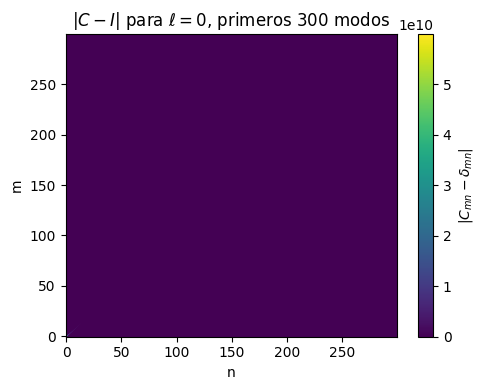

In [23]:
ell_show = 0

C = Cs[ell_show]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(np.abs(C - np.eye(C.shape[0])), origin="lower", aspect="auto")
ax.set_title(fr"$|C-I|$ para $\ell={ell_show}$, primeros {C.shape[0]} modos")
ax.set_xlabel("n")
ax.set_ylabel("m")
plt.colorbar(im, ax=ax, label=r"$|C_{mn}-\delta_{mn}|$")

plt.tight_layout()
plt.show()

In [24]:
def residual_report(f, ell, n_check=300):
    r = f["r"][:]
    diagA, offA, M, Bdiag, Boff = build_A_M(r, ell)

    k, R = read_modes_for_ell(f, ell)

    n = min(n_check, R.shape[1])
    Rn = R[:, :n]
    lam = k[:n]**2

    AR = apply_tridiag(diagA, offA, Rn)
    MR = M[:, None]*Rn

    Res = AR - MR*lam[None, :]

    denom = (
        np.linalg.norm(AR, axis=0)
        + np.abs(lam)*np.linalg.norm(MR, axis=0)
        + 1.0e-300
    )

    rel_res = np.linalg.norm(Res, axis=0)/denom

    # Rayleigh quotient: lambda = (R^T A R)/(R^T M R)
    num = np.sum(Rn*AR, axis=0)
    den = np.sum(Rn*MR, axis=0)
    lam_ray = num/den

    rel_ray = np.abs(lam_ray - lam)/(np.abs(lam_ray) + np.abs(lam) + 1.0e-300)

    return {
        "ell": ell,
        "n_check": n,
        "max_rel_residual": np.max(rel_res),
        "median_rel_residual": np.median(rel_res),
        "max_rel_rayleigh_vs_k2": np.max(rel_ray),
        "median_rel_rayleigh_vs_k2": np.median(rel_ray),
        "min_lambda_rayleigh": np.min(lam_ray),
        "max_lambda_rayleigh": np.max(lam_ray),
    }, rel_res, rel_ray, lam_ray, lam

rows = []
residuals = {}
rayleighs = {}

with h5py.File(H5FILE, "r") as f:
    for group in get_ell_groups(f):
        ell = int(group.split("_")[1])
        rep, rel_res, rel_ray, lam_ray, lam = residual_report(f, ell, N_CHECK)
        rows.append(rep)
        residuals[ell] = rel_res
        rayleighs[ell] = rel_ray

df_res = pd.DataFrame(rows)
df_res

,ell,n_check,max_rel_residual,median_rel_residual,max_rel_rayleigh_vs_k2,median_rel_rayleigh_vs_k2,min_lambda_rayleigh,max_lambda_rayleigh
0,0,300,1.000000,0.993326,1.000000,0.990893,0.102440,0.652239
1,1,300,1.000000,0.993525,1.000000,0.991748,0.041334,0.659233
2,2,300,1.000000,0.993529,0.999999,0.990870,0.075260,0.642743
3,3,300,0.999999,0.993700,0.999999,0.991604,0.081703,0.660928
4,4,300,0.999999,0.993060,0.999998,0.990387,0.128182,0.625163
5,5,300,0.999999,0.992579,0.999998,0.989349,0.255817,0.648340


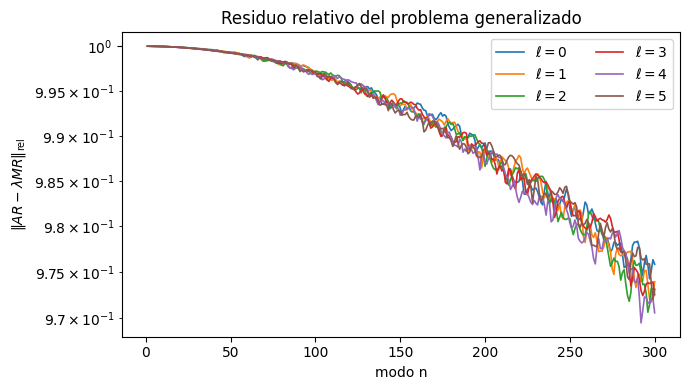

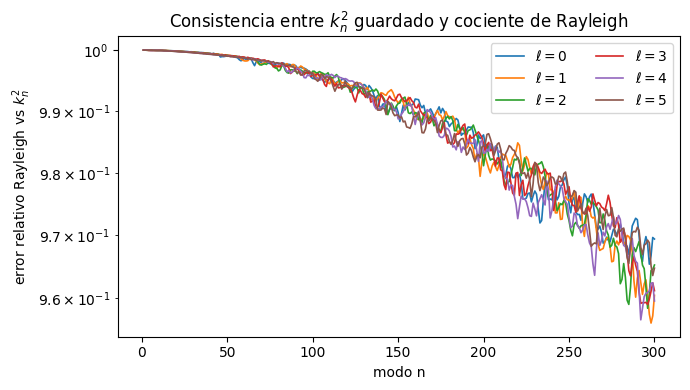

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))

for ell, rel_res in residuals.items():
    ax.semilogy(np.arange(1, len(rel_res) + 1), rel_res, lw=1.2, label=fr"$\ell={ell}$")

ax.set_xlabel("modo n")
ax.set_ylabel(r"$\|AR-\lambda MR\|_{\mathrm{rel}}$")
ax.set_title("Residuo relativo del problema generalizado")
ax.legend(ncol=2)
ax.grid(False)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))

for ell, rel_ray in rayleighs.items():
    ax.semilogy(np.arange(1, len(rel_ray) + 1), rel_ray, lw=1.2, label=fr"$\ell={ell}$")

ax.set_xlabel("modo n")
ax.set_ylabel(r"error relativo Rayleigh vs $k_n^2$")
ax.set_title(r"Consistencia entre $k_n^2$ guardado y cociente de Rayleigh")
ax.legend(ncol=2)
ax.grid(False)

plt.tight_layout()
plt.show()

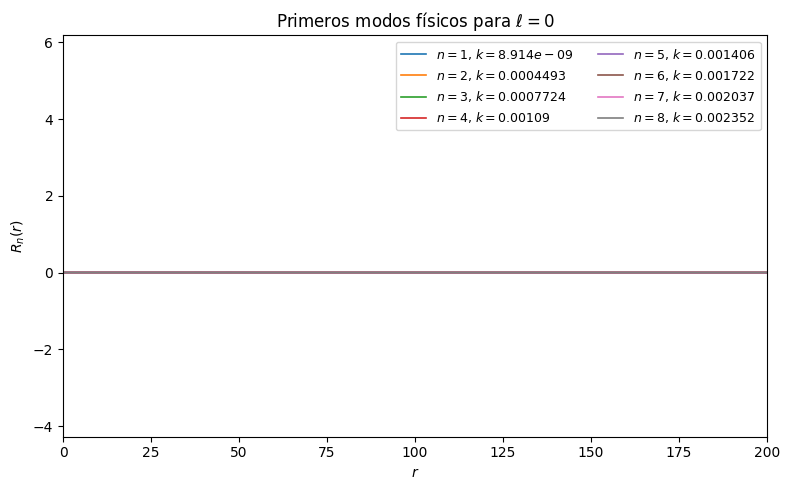

In [26]:
ell_show = 0

with h5py.File(H5FILE, "r") as f:
    r = f["r"][:]
    ri, dr_edge, drc, M = grid_quantities(r)
    k, R = read_modes_for_ell(f, ell_show)

fig, ax = plt.subplots(figsize=(8, 5))

for j in range(min(N_PLOT, R.shape[1])):
    ax.plot(ri, R[:, j], lw=1.2, label=fr"$n={j+1}$, $k={k[j]:.4g}$")

ax.set_xlim(0, min(200, ri[-1]))
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$R_n(r)$")
ax.set_title(fr"Primeros modos físicos para $\ell={ell_show}$")
ax.legend(ncol=2, fontsize=9)
ax.grid(False)

plt.tight_layout()
plt.show()

In [27]:
def project_real_function(R, M, f):
    """
    Coeficientes c_n = <R_n, f>_M = sum_i R_i,n f_i M_i
    """
    return R.T @ (M*f)

def reconstruct_from_coeffs(R, c, n=None):
    if n is None:
        n = len(c)
    return R[:, :n] @ c[:n]

def M_norm(M, f):
    return np.sqrt(np.sum(M*np.abs(f)**2))

ell_show = 0
r0 = 80.0
sigma = 10.0
k0 = 1.5

with h5py.File(H5FILE, "r") as f:
    r = f["r"][:]
    ri, dr_edge, drc, M = grid_quantities(r)
    k, R = read_modes_for_ell(f, ell_show)

# Perfil real de prueba. Para una función compleja, proyecta Re e Im por separado.
f_test = np.exp(-(ri - r0)**2/(2.0*sigma**2))*np.cos(k0*ri)

c = project_real_function(R, M, f_test)

n_list = [5, 10, 20, 50, 100, 200, 500, 1000, 2000, R.shape[1]]
n_list = [n for n in n_list if n <= R.shape[1]]

rows = []

for n in n_list:
    f_rec = reconstruct_from_coeffs(R, c, n=n)
    err = M_norm(M, f_test - f_rec)/M_norm(M, f_test)
    rows.append({"n_modes": n, "rel_L2M_error": err})

df_recon = pd.DataFrame(rows)
df_recon

,n_modes,rel_L2M_error
0,5,1413.104457
1,10,1461.117672
2,20,1437.447295
3,50,1437.448630
4,100,1437.441604
5,200,1437.441557
6,500,1437.441553
7,1000,1437.441553
8,2000,1437.441553
9,5125,1437.441553


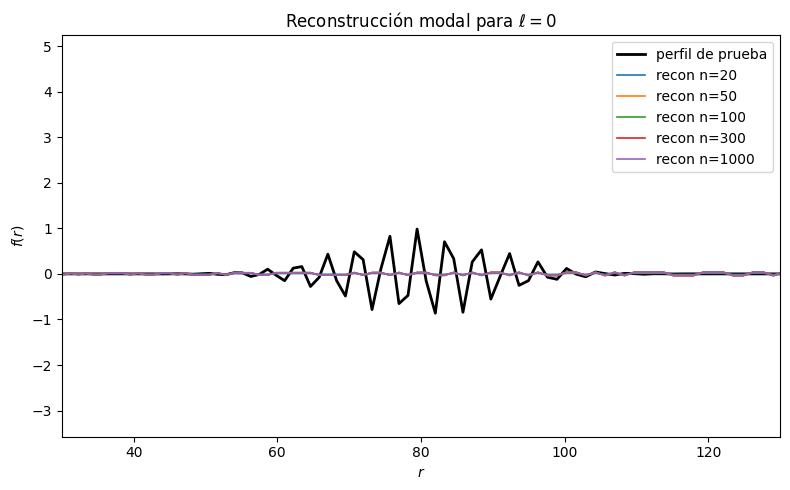

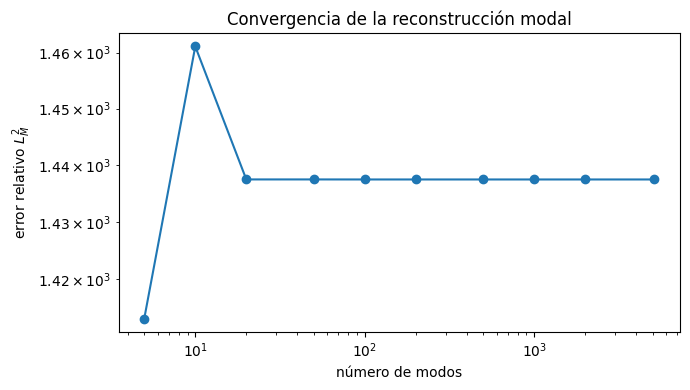

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(ri, f_test, lw=2.0, label="perfil de prueba", color="black")

for n in [20, 50, 100, 300, 1000]:
    if n <= R.shape[1]:
        f_rec = reconstruct_from_coeffs(R, c, n=n)
        ax.plot(ri, f_rec, lw=1.2, label=f"recon n={n}")

ax.set_xlim(r0 - 5*sigma, r0 + 5*sigma)
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$f(r)$")
ax.set_title(fr"Reconstrucción modal para $\ell={ell_show}$")
ax.legend()
ax.grid(False)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(df_recon["n_modes"], df_recon["rel_L2M_error"], marker="o")
ax.set_xlabel("número de modos")
ax.set_ylabel(r"error relativo $L^2_M$")
ax.set_title("Convergencia de la reconstrucción modal")
ax.grid(False)

plt.tight_layout()
plt.show()

In [29]:
rows = []

with h5py.File(H5FILE, "r") as f:
    for group in get_ell_groups(f):
        ell = int(group.split("_")[1])
        k, R = read_modes_for_ell(f, ell)

        rows.append({
            "ell": ell,
            "n_saved": len(k),
            "k_max_saved": k[-1],
            "n_modes_k_le_10": int(np.sum(k <= 10.0)),
            "last_k_le_10": np.max(k[k <= 10.0]) if np.any(k <= 10.0) else np.nan,
            "first_k_gt_10": np.min(k[k > 10.0]) if np.any(k > 10.0) else np.nan,
        })

df_k10 = pd.DataFrame(rows)
df_k10

,ell,n_saved,k_max_saved,n_modes_k_le_10,last_k_le_10,first_k_gt_10
0,0,5125,13.345057,5121,9.296318,10.139354
1,1,5125,15.087022,5120,9.964591,10.575242
2,2,5125,25.032154,5118,9.462522,10.334663
3,3,5125,35.019628,5117,9.418298,10.366867
4,4,5125,45.014245,5116,9.229378,10.232995
5,5,5125,55.011240,5116,9.983334,11.066233


In [30]:
df_summary = (
    df_spectrum
    .merge(df_ortho, on="ell", how="left", suffixes=("", "_ortho"))
    .merge(df_res, on="ell", how="left", suffixes=("", "_res"))
    .merge(df_k10[["ell", "n_modes_k_le_10", "last_k_le_10", "first_k_gt_10"]], on="ell", how="left")
)

cols = [
    "ell",
    "Nr",
    "n_modes",
    "k_min",
    "k_max",
    "n_modes_k_le_10",
    "max_abs_diag_minus_1",
    "max_abs_offdiag",
    "max_rel_residual",
    "max_rel_rayleigh_vs_k2",
    "monotonic_k",
]

df_summary[cols]

,ell,Nr,n_modes,k_min,k_max,n_modes_k_le_10,max_abs_diag_minus_1,max_abs_offdiag,max_rel_residual,max_rel_rayleigh_vs_k2,monotonic_k
0,0,5125,5125,8.913560e-09,13.345057,5121,5.989940e+10,1.808623e+08,1.000000,1.000000,True
1,1,5125,5125,2.081629e-04,15.087022,5120,3.959288e+10,1.235764e+09,1.000000,1.000000,True
2,2,5125,5125,3.342172e-04,25.032154,5118,3.939135e+10,3.944103e+08,1.000000,0.999999,True
3,3,5125,5125,4.514206e-04,35.019628,5117,3.937467e+10,1.949324e+08,0.999999,0.999999,True
4,4,5125,5125,5.646839e-04,45.014245,5116,3.937121e+10,1.164078e+08,0.999999,0.999998,True
5,5,5125,5125,6.756622e-04,55.011240,5116,3.937014e+10,7.742140e+07,0.999999,0.999998,True


In [31]:
def diagnose_modes_storage(f, ell, ntest=50):
    r = f["r"][:]
    ri, dr_edge, drc, M = grid_quantities(r)
    Nr = len(M)

    A = f[f"ell_{ell:04d}/modes"][:]
    k = f[f"ell_{ell:04d}/k"][:]
    n_save = len(k)

    print(f"ell={ell}")
    print(f"Nr={Nr}, n_save={n_save}")
    print(f"HDF5 modes shape = {A.shape}")
    print(f"k shape          = {k.shape}")

    candidates = {}

    # Interpretación directa
    if A.shape == (Nr, n_save):
        candidates["direct_A[i,n]"] = A

    # Interpretación transpuesta usual Fortran/Python
    if A.shape == (n_save, Nr):
        candidates["transpose_A[n,i].T"] = A.T

    # Reparación por orden de memoria: bytes en orden C reinterpretados como Fortran
    if A.size == Nr*n_save:
        candidates["reshape_C_to_Fortran"] = A.ravel(order="C").reshape((Nr, n_save), order="F")

    # Otra reparación posible
    if A.size == Nr*n_save:
        candidates["reshape_Fortran_to_C"] = A.ravel(order="F").reshape((Nr, n_save), order="C")

    rows = []

    for name, R in candidates.items():
        n = min(ntest, R.shape[1])

        Rn = R[:, :n]
        C = (Rn*M[:, None]).T @ Rn

        diag = np.diag(C)
        off = C - np.diag(diag)

        rows.append({
            "candidate": name,
            "R_shape": str(R.shape),
            "min_norm": np.min(diag),
            "max_norm": np.max(diag),
            "max_abs_diag_minus_1": np.max(np.abs(diag - 1.0)),
            "max_abs_offdiag": np.max(np.abs(off)),
            "median_abs_R": np.median(np.abs(Rn)),
            "max_abs_R": np.max(np.abs(Rn)),
        })

    return pd.DataFrame(rows)

with h5py.File(H5FILE, "r") as f:
    df_diag_modes = diagnose_modes_storage(f, ell=0, ntest=50)

df_diag_modes

ell=0
Nr=5125, n_save=5125
HDF5 modes shape = (5125, 5125)
k shape          = (5125,)


,candidate,R_shape,min_norm,max_norm,max_abs_diag_minus_1,max_abs_offdiag,median_abs_R,max_abs_R
0,"direct_A[i,n]","(5125, 5125)",279839.30628,5.989940e+10,5.989940e+10,1.808623e+08,0.001127,5.705155
1,"transpose_A[n,i].T","(5125, 5125)",1.00000,1.000000e+00,3.552714e-15,2.872702e-15,0.000002,0.000222
2,reshape_C_to_Fortran,"(5125, 5125)",1.00000,1.000000e+00,3.552714e-15,2.872702e-15,0.000002,0.000222
3,reshape_Fortran_to_C,"(5125, 5125)",1.00000,1.000000e+00,3.552714e-15,2.872702e-15,0.000002,0.000222


In [32]:
def read_modes_for_ell_auto(f, ell, ntest=50, verbose=False):
    r = f["r"][:]
    ri, dr_edge, drc, M = grid_quantities(r)
    Nr = len(M)

    group = f[f"ell_{ell:04d}"]
    k = group["k"][:]
    A = group["modes"][:]
    n_save = len(k)

    candidates = {}

    if A.shape == (Nr, n_save):
        candidates["direct_A[i,n]"] = A

    if A.shape == (n_save, Nr):
        candidates["transpose_A[n,i].T"] = A.T

    if A.size == Nr*n_save:
        candidates["reshape_C_to_Fortran"] = A.ravel(order="C").reshape((Nr, n_save), order="F")
        candidates["reshape_Fortran_to_C"] = A.ravel(order="F").reshape((Nr, n_save), order="C")

    if len(candidates) == 0:
        raise ValueError(
            f"No pude interpretar modes.shape={A.shape} con Nr={Nr}, n_save={n_save}"
        )

    best_name = None
    best_R = None
    best_score = np.inf
    best_report = None

    for name, R in candidates.items():
        n = min(ntest, R.shape[1])
        Rn = R[:, :n]

        C = (Rn*M[:, None]).T @ Rn
        diag = np.diag(C)
        off = C - np.diag(diag)

        diag_err = np.max(np.abs(diag - 1.0))
        off_err = np.max(np.abs(off))
        score = diag_err + off_err

        if score < best_score:
            best_score = score
            best_name = name
            best_R = R
            best_report = {
                "candidate": name,
                "diag_err": diag_err,
                "off_err": off_err,
                "score": score,
                "shape": R.shape,
            }

    if verbose:
        print("Interpretación seleccionada:")
        for key, val in best_report.items():
            print(f"  {key}: {val}")

    return k, np.asarray(best_R, dtype=np.float64), best_report

In [33]:
def orthonormality_report_auto(f, ell, n_check=300):
    r = f["r"][:]
    ri, dr_edge, drc, M = grid_quantities(r)

    k, R, rep_read = read_modes_for_ell_auto(f, ell, verbose=False)

    n = min(n_check, R.shape[1])
    Rn = R[:, :n]

    C = (Rn*M[:, None]).T @ Rn

    diag = np.diag(C)
    off = C - np.diag(diag)

    return {
        "ell": ell,
        "reader": rep_read["candidate"],
        "n_check": n,
        "max_abs_diag_minus_1": np.max(np.abs(diag - 1.0)),
        "max_abs_offdiag": np.max(np.abs(off)),
        "fro_norm_C_minus_I": np.linalg.norm(C - np.eye(n), ord="fro"),
    }, C

rows = []
Cs = {}

with h5py.File(H5FILE, "r") as f:
    for group in get_ell_groups(f):
        ell = int(group.split("_")[1])
        rep, C = orthonormality_report_auto(f, ell, N_CHECK)
        rows.append(rep)
        Cs[ell] = C

df_ortho_auto = pd.DataFrame(rows)
df_ortho_auto

,ell,reader,n_check,max_abs_diag_minus_1,max_abs_offdiag,fro_norm_C_minus_I
0,0,"transpose_A[n,i].T",300,4.884981e-15,3.230055e-15,1.289878e-13
1,1,"transpose_A[n,i].T",300,4.218847e-15,3.060052e-15,1.295193e-13
2,2,"transpose_A[n,i].T",300,4.884981e-15,3.649858e-15,1.302691e-13
3,3,"transpose_A[n,i].T",300,6.217249e-15,3.472916e-15,1.308362e-13
4,4,"transpose_A[n,i].T",300,5.884182e-15,3.046174e-15,1.311596e-13
5,5,"transpose_A[n,i].T",300,4.662937e-15,2.411266e-15,1.287113e-13


In [34]:
def residual_report_auto(f, ell, n_check=300):
    r = f["r"][:]
    diagA, offA, M, Bdiag, Boff = build_A_M(r, ell)

    k, R, rep_read = read_modes_for_ell_auto(f, ell, verbose=False)

    n = min(n_check, R.shape[1])
    Rn = R[:, :n]
    lam = k[:n]**2

    AR = apply_tridiag(diagA, offA, Rn)
    MR = M[:, None]*Rn

    Res = AR - MR*lam[None, :]

    denom = (
        np.linalg.norm(AR, axis=0)
        + np.abs(lam)*np.linalg.norm(MR, axis=0)
        + 1.0e-300
    )

    rel_res = np.linalg.norm(Res, axis=0)/denom

    num = np.sum(Rn*AR, axis=0)
    den = np.sum(Rn*MR, axis=0)
    lam_ray = num/den

    rel_ray = np.abs(lam_ray - lam)/(np.abs(lam_ray) + np.abs(lam) + 1.0e-300)

    return {
        "ell": ell,
        "reader": rep_read["candidate"],
        "n_check": n,
        "max_rel_residual": np.max(rel_res),
        "median_rel_residual": np.median(rel_res),
        "max_rel_rayleigh_vs_k2": np.max(rel_ray),
        "median_rel_rayleigh_vs_k2": np.median(rel_ray),
        "min_lambda_rayleigh": np.min(lam_ray),
        "max_lambda_rayleigh": np.max(lam_ray),
    }, rel_res, rel_ray

rows = []
residuals_auto = {}
rayleighs_auto = {}

with h5py.File(H5FILE, "r") as f:
    for group in get_ell_groups(f):
        ell = int(group.split("_")[1])
        rep, rel_res, rel_ray = residual_report_auto(f, ell, N_CHECK)
        rows.append(rep)
        residuals_auto[ell] = rel_res
        rayleighs_auto[ell] = rel_ray

df_res_auto = pd.DataFrame(rows)
df_res_auto

,ell,reader,n_check,max_rel_residual,median_rel_residual,max_rel_rayleigh_vs_k2,median_rel_rayleigh_vs_k2,min_lambda_rayleigh,max_lambda_rayleigh
0,0,"transpose_A[n,i].T",300,9.778631e-01,1.059715e-12,1.000000e+00,3.219353e-14,-1.914142e-19,0.008821
1,1,"transpose_A[n,i].T",300,3.820926e-08,1.058238e-12,5.070673e-10,4.173575e-14,4.333181e-08,0.008852
2,2,"transpose_A[n,i].T",300,1.401821e-08,1.036468e-12,2.939278e-10,5.368229e-14,1.117011e-07,0.008882
3,3,"transpose_A[n,i].T",300,7.392691e-09,1.021324e-12,1.886238e-10,8.877195e-14,2.037806e-07,0.008912
4,4,"transpose_A[n,i].T",300,4.803780e-09,1.012627e-12,1.160643e-10,2.942013e-14,3.188679e-07,0.008942
5,5,"transpose_A[n,i].T",300,3.261925e-09,1.022637e-12,4.894463e-11,5.146947e-14,4.565194e-07,0.008971
